# Notebook to develop codes:

**Remark:** 
 * I work in my local branch (edmond-dev)
 * For now it turns with `desilike/dr2-dev`

In [1]:
import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [2]:
from tools import read_data, rebin_data, get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

In [3]:
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[000000.00] [0/1] 06-16 10:29  FIT PNG                   INFO     Load data from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/


In [4]:
def propose_fiducial():
    propose_fiducial = {}

    use_ell2 = True

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': use_ell2, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                               'use_ell2': use_ell2, 'kmin': 1e-2, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': use_ell2, 'kmin': 3e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': use_ell2, 'kmin': 4e-3, 'kmax': 0.08, 'kmin_ell2': 3e-3, 'kmax_ell2': 0.08}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': use_ell2, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                                   'use_ell2': use_ell2, 'kmin': 4e-3, 'kmax': 0.08, 'kmin_ell2': 3e-3, 'kmax_ell2': 0.08}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']
      
    return propose_fiducial

In [5]:
fiducial = propose_fiducial()
tracers_to_read = ['LRG', 'ELGnotqso', 'QSO', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO']

aladr1 = True

pks, windows, covs, mocks, zeffs = {}, {}, {}, {}, {}
for tracer in tracers_to_read:
    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, window_extra='RIC+AMR', weight_type_mocks='default-fkp-oqe', **fiducial[short_tracer])
    
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, **fiducial[short_tracer])
    
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except ValueError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')
   
    if 'x' not in short_tracer: short_tracer = 'x'.join(2*[short_tracer])
    pks[short_tracer], windows[short_tracer], covs[short_tracer], mocks[short_tracer] = pk, window, cov, mock

    zeffs[short_tracer] = {}
    zeffs[short_tracer][0] = windows[short_tracer].observable.get(0).attrs['zeff']
    try: 
        zeffs[short_tracer][2] = windows[short_tracer].observable.get(2).attrs['zeff']
    except ValueError:
        pass

[000000.04] [0/1] 06-16 10:29  PNG fitting tools         INFO     Reading the window with window_extra='RIC+AMR'


[000007.11] [0/1] 06-16 10:29  FIT PNG                   INFO     After rebinning and k range selection: 29 and 13 data points.
[000007.12] [0/1] 06-16 10:29  PNG fitting tools         INFO     Reading the window with window_extra='RIC+AMR'
[000014.98] [0/1] 06-16 10:29  FIT PNG                   INFO     After rebinning and k range selection: 20 and 13 data points.
[000015.00] [0/1] 06-16 10:29  PNG fitting tools         INFO     Reading the window with window_extra='RIC+AMR'
[000021.85] [0/1] 06-16 10:29  FIT PNG                   INFO     After rebinning and k range selection: 27 and 13 data points.
[000021.86] [0/1] 06-16 10:29  PNG fitting tools         INFO     Reading the window with window_extra='RIC+AMR'
[000027.94] [0/1] 06-16 10:30  FIT PNG                   INFO     After rebinning and k range selection: 26 and 12 data points.
[000027.95] [0/1] 06-16 10:30  PNG fitting tools         INFO     Reading the window with window_extra='RIC+AMR'
[000035.07] [0/1] 06-16 10:30  FIT P

In [6]:
tracers = ['LRGxLRG', 'ELGxELG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']

analytical_covariance = False

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_cross_ell0.b1': 2.15, 'ELG_cross_ell0.b1': 1.2}

observables, likelihoods, profilers = {}, {}, {}
for tracer in tracers:
    covariance = covs[tracer] if analytical_covariance else mocks[tracer]
    observables[tracer], likelihoods[tracer] = get_observable_and_likelihood(pks[tracer], windows[tracer], covariance, 
                                                                             tracer, zeffs, nickname=tracer, engine='camb', **kwargs)
    profilers[tracer] = run_profiler(likelihoods[tracer])

[000033.07] [0/1] 06-10 09:44  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[000033.25] [0/1] 06-10 09:44  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[000033.32] [0/1] 06-10 09:44  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000033.43] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     Covariance matrix with 42 points built from 1000 observations.
[000033.43] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9570.
[000035.48] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     Covariance matrix with 42 points built from 1000 observations, varying 4 parameters.
[000035.48] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0344.
[000036.26] [0/1] 06-10 09:44  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0

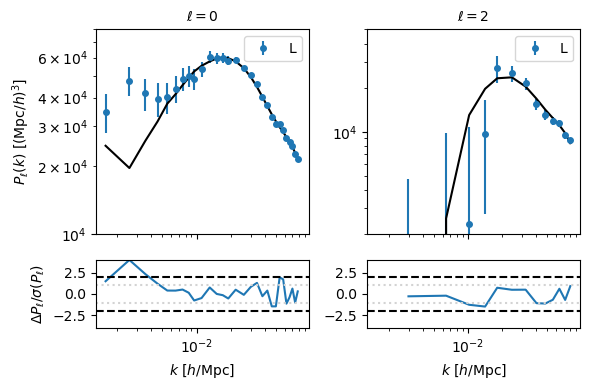

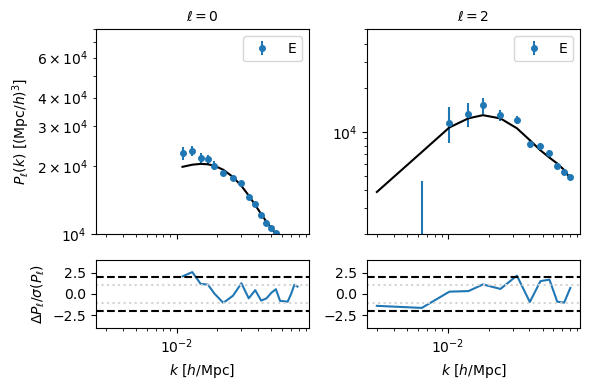

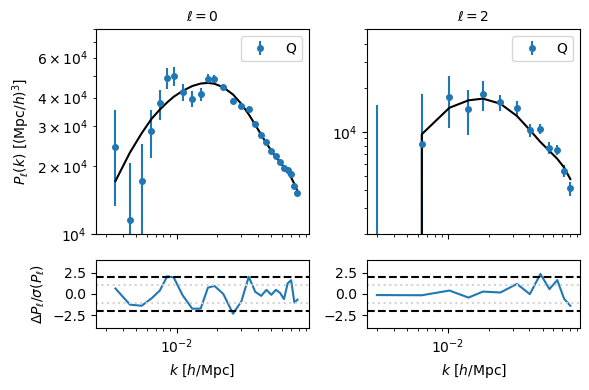

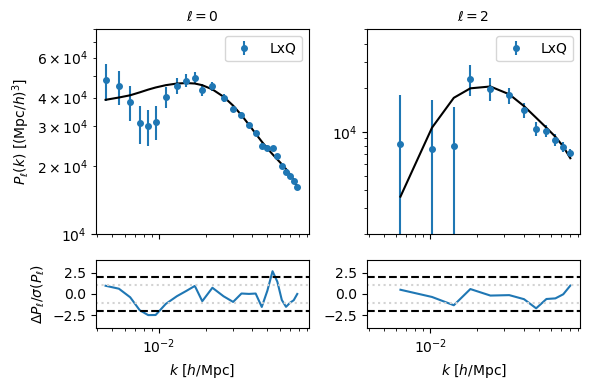

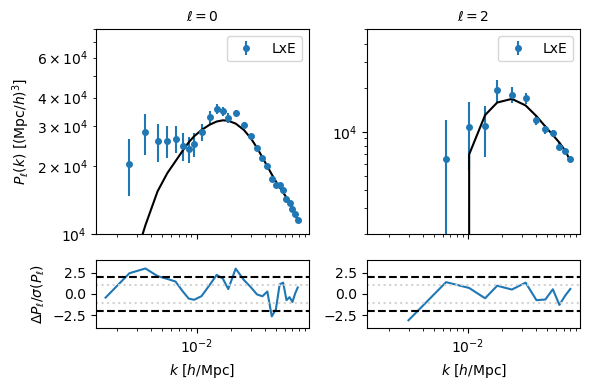

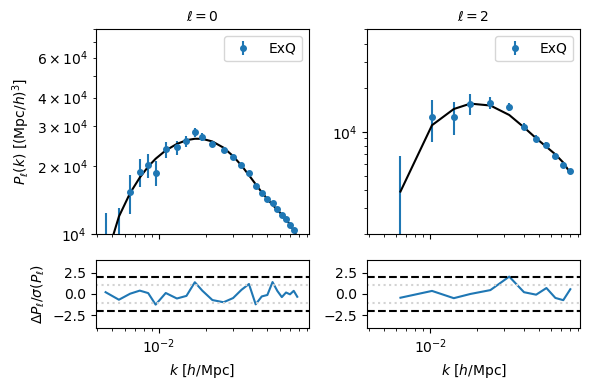

In [7]:
#plot_observables(observables)
for tracer in observables.keys():
    plot_observables({tracer: observables[tracer]})

[000056.38] [0/1] 06-10 09:44  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000056.80] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     Covariance matrix with 200 points built from 1000 observations.
[000056.80] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.7988.
[000062.60] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     Covariance matrix with 200 points built from 1000 observations, varying 14 parameters.
[000062.60] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.2106.
[000062.68] [0/1] 06-10 09:44  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'ELG_ELGxQSO_ell0xQSO_ELGxQSO_ell0.sn0', 'ELG_ELGxQSO_ell0.b1', 'QSO_ELGxQSO_ell0.sigmas', 'LRG_LRGxELG_ell0xELG_LRGxELG_ell0.sn0', 'ELG_LRGxELG_ell0.sigmas', 'LRG_LRGxQSO_ell0xQSO_LRGxQSO_ell0.sn0', 'QSO_LRGxQSO_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'Q

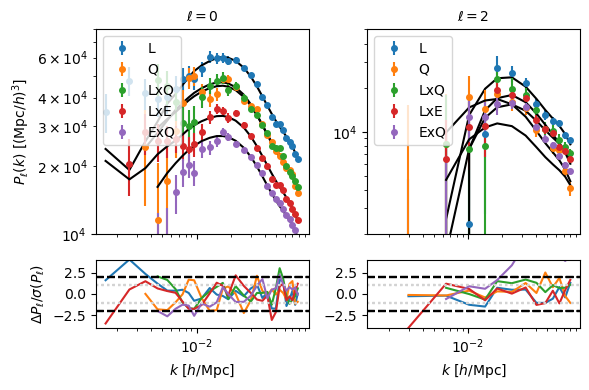

[000076.76] [0/1] 06-10 09:44  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000077.26] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     Covariance matrix with 233 points built from 1000 observations.
[000077.26] [0/1] 06-10 09:44  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.7658.
[000087.37] [0/1] 06-10 09:45  ObservablesGaussianLikelihood INFO     Covariance matrix with 233 points built from 1000 observations, varying 16 parameters.
[000087.37] [0/1] 06-10 09:45  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.2561.
[000087.45] [0/1] 06-10 09:45  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'ELG_ELGxQSO_ell0xQSO_ELGxQSO_ell0.sn0', 'QSO_ELGxQSO_ell0.sigmas', 'LRG_LRGxELG_ell0xELG_LRGxELG_ell0.sn0', 'ELG_LRGxELG_ell0.sigmas', 'LRG_LRGxQSO_ell0xQSO_LRGxQSO_ell0.sn0', 'QSO_LRGxQSO_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas', 'QSO_e

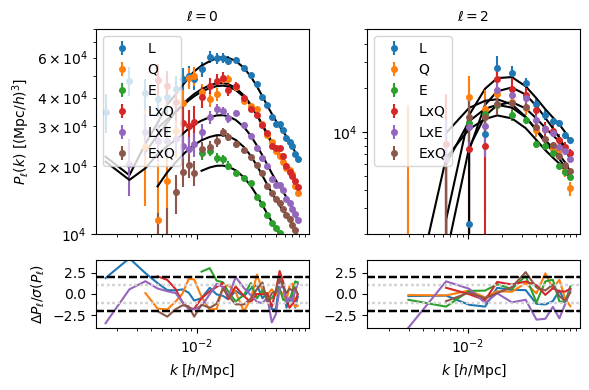

In [ ]:
#orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]
orders += [['LRGxLRG', 'QSOxQSO', 'ELGxELG', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

for order in orders:

    obs = {tracer: get_observable_and_likelihood(pks[tracer], windows[tracer], covs if analytical_covariance else mocks[tracer], 
                                                 tracer, zeffs, nickname=tracer, drop_ell2_cross=True, engine='camb', **kwargs)[-1] for tracer in order}

    likelihoods['-'.join(order)] = build_total_likelihood(order, pks, obs, covs if analytical_covariance else mocks, zeffs, fiducial)

    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tracer: obs[tracer] for tracer in order})

In [9]:
# Run mcmc:
samplers = {}

for tracer in likelihoods.keys():
    logger.info(f'Run MCMC for {tracer=}:')
    samplers[tracer] =  run_mcmc(likelihoods[tracer], max_iterations=20000, check_every=10000)

[000110.94] [0/1] 06-10 09:45  FIT PNG                   INFO     Run MCMC for tracer='LRGxLRG':
[000110.95] [0/1] 06-10 09:45  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[None]
[000111.78] [0/1] 06-10 09:45  EmceeSampler              INFO     Successfully vmap input likelihood.
[000111.99] [0/1] 06-10 09:45  EmceeSampler              INFO     Successfully jit input likelihood.


100%|██████████| 10000/10000 [00:37<00:00, 267.00it/s]


[000149.90] [0/1] 06-10 09:46  Chain                     INFO     Saving tmp/mcmc_output_0.npy.


100%|██████████| 10000/10000 [00:36<00:00, 277.78it/s]


[000185.98] [0/1] 06-10 09:46  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[000185.99] [0/1] 06-10 09:46  FIT PNG                   INFO     Run MCMC for tracer='ELGxELG':
[000185.99] [0/1] 06-10 09:46  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas'].
[None]
[000186.10] [0/1] 06-10 09:46  EmceeSampler              INFO     Successfully vmap input likelihood.
[000186.30] [0/1] 06-10 09:46  EmceeSampler              INFO     Successfully jit input likelihood.


...

[001217.47] [0/1] 06-10 10:03  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[001218.03] [0/1] 06-10 10:03  FIT PNG                   INFO     Run MCMC for tracer='LRGxLRG-QSOxQSO-ELGxELG-LRGxQSO-LRGxELG-ELGxQSO':
[001218.03] [0/1] 06-10 10:03  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'ELG_ELGxQSO_ell0xQSO_ELGxQSO_ell0.sn0', 'QSO_ELGxQSO_ell0.sigmas', 'LRG_LRGxELG_ell0xELG_LRGxELG_ell0.sn0', 'ELG_LRGxELG_ell0.sigmas', 'LRG_LRGxQSO_ell0xQSO_LRGxQSO_ell0.sn0', 'QSO_LRGxQSO_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[None]
[001218.60] [0/1] 06-10 10:03  EmceeSampler              INFO     Successfully vmap input likelihood.
[001219.52] [0/1] 06-10 10:03  EmceeSampler              INFO     Successfully jit input likelihood.


100%|██████████| 10000/10000 [05:27<00:00, 30.54it/s]


[001548.75] [0/1] 06-10 10:09  Chain                     INFO     Saving tmp/mcmc_output_0.npy.


100%|██████████| 10000/10000 [05:00<00:00, 33.30it/s]


[001850.01] [0/1] 06-10 10:14  Chain                     INFO     Saving tmp/mcmc_output_0.npy.


Nbr points for tracer='LRGxLRG': 14000
Nbr points for tracer='ELGxELG': 14000
Nbr points for tracer='QSOxQSO': 14000
Nbr points for tracer='LRGxQSO': 14000
Nbr points for tracer='LRGxELG': 14000
Nbr points for tracer='ELGxQSO': 14000
Nbr points for tracer='LRGxLRG-QSOxQSO-LRGxQSO-LRGxELG-ELGxQSO': 50400
Nbr points for tracer='LRGxLRG-QSOxQSO-ELGxELG-LRGxQSO-LRGxELG-ELGxQSO': 56000


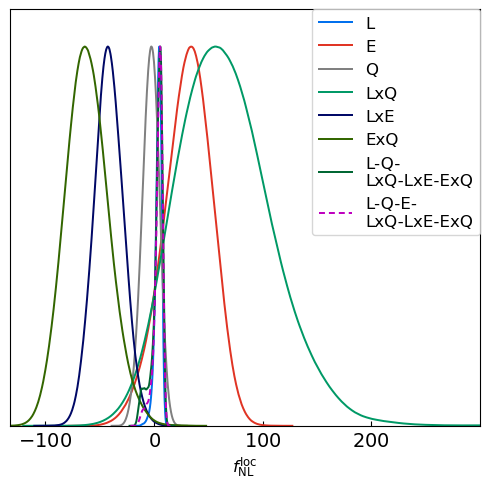

In [10]:
from desilike.samples import Chain
burnin, thin = 0.3, 10

translator = {'LRGxLRG': 'L', 'ELGxELG': 'E', 'QSOxQSO': 'Q', 'LRGxQSO': 'LxQ', 'LRGxELG': 'LxE', 'ELGxQSO': 'ExQ'}
translator['LRGxLRG-QSOxQSO-LRGxQSO'] = 'L-Q-LxQ'
translator['LRGxLRG-QSOxQSO-LRGxQSO-LRGxELG-ELGxQSO'] = 'L-Q-\nLxQ-LxE-ExQ'
translator['LRGxLRG-QSOxQSO-ELGxELG-LRGxQSO-LRGxELG-ELGxQSO'] = 'L-Q-E-\nLxQ-LxE-ExQ'

chains = {}
for tracer in samplers.keys():
     # to load chains from a disk:
     #chains = Chain.concatenate([Chain.load(fn_chains[key].replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(nchains)])
     
     chains[tracer] = Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in samplers[tracer].chains])
     print(f'Nbr points for {tracer=}: {chains[tracer]["fnl_loc"].size}')

from tools import get_getdist_plotter, plot_triangle
g = get_getdist_plotter(fig_width_inch=5)

plot_triangle([chains[tracer] for tracer in chains.keys()],  ['fnl_loc'], legend_labels=list(translator[tracer] for tracer in chains.keys()), 
              xlabels=[r'$f_{\rm NL}^{\rm loc}$'], g=g)

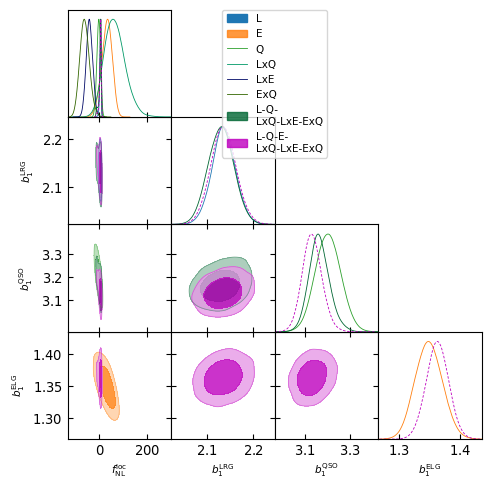

In [11]:
params = ['fnl_loc', 'LRG_ell0.b1', 'QSO_ell0.b1', 'ELG_ell0.b1']
xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1^{\rm LRG}$', r'$b_1^{\rm QSO}$', r'$b_1^{\rm ELG}$']
plot_triangle([chains[tracer] for tracer in chains.keys()], params, legend_labels=list(translator[tracer] for tracer in chains.keys()), xlabels=xlabels, 
              filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

## Display the combined analytical covariance matrix:

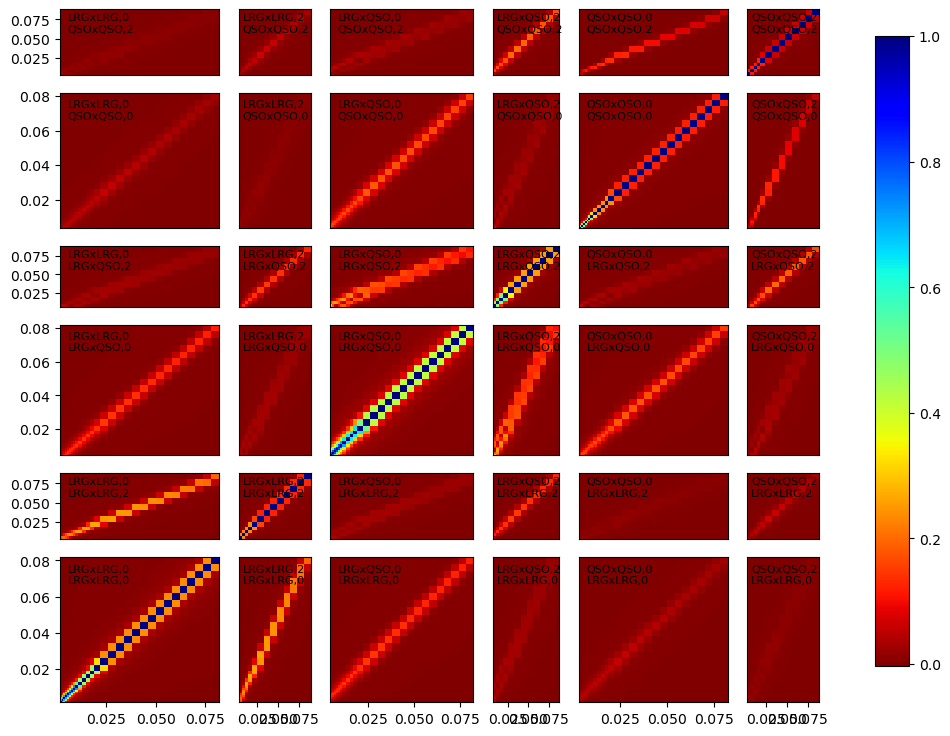

In [12]:
def plot_corr(cov, fn=None): 
    import matplotlib.text
    import re
    
    fig = cov.plot(corrcoef=True, figsize=(9,9))
    for txt in fig.findobj(matplotlib.text.Text):
        s = txt.get_text()
        s = s.replace('spectrum2,', '').replace(',spectrum2', '').replace('spectrum2', '')
        s = re.sub(r'\b(\w+)_\1\b', r'\1', s)   # LRG_LRG -> LRG
        s = s.replace('_', 'x')                 # LRG_QSO -> LRGxQSO
        s = s.replace('\nx ', '\n')             # remove "x " prefix on second line
        if '\n' in s: txt.set_fontsize(8)
        txt.set_text(s)
    if fn is not None: plt.savefig(fn)
    plt.show()

from tools import combine_analytical_covariances

order = ['LRGxLRG', 'LRGxQSO', 'QSOxQSO']

combined_cov = combine_analytical_covariances(pks, covs, order=order, fiducial=fiducial)
plot_corr(combined_cov)